**Install & Import Libraries**

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**Load Dataset**

In [3]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Country-data.csv")
df.head()

Saving Country-data.csv to Country-data (1).csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Data Cleaning**

Perform all of these:
* Remove whitespace from column names
* Remove duplicate rows
* Convert columns to numeric
* Fill missing values using median




In [4]:
df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.fillna(df.median(numeric_only=True), inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


**Feature Selection & Standardization**

In [5]:
X = df.drop("country", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Elbow Method**

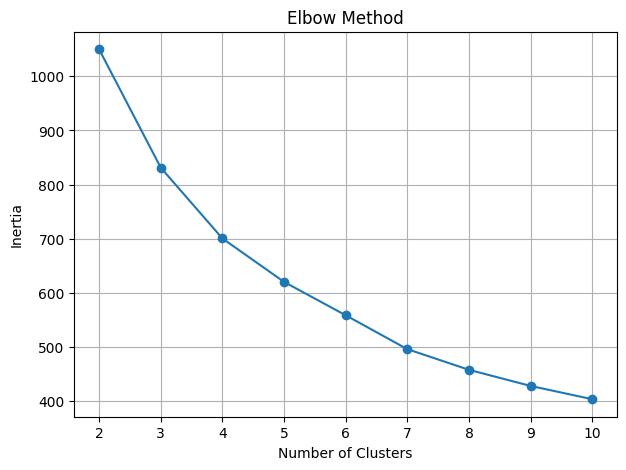

In [6]:
inertia = []

for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

**Train KMeans**

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

**Silhouette Score**

In [8]:
score = silhouette_score(X_scaled, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126


**DBSCAN**

Parameters given by assignment:

* eps = 1.5
* min_samples = 5

In [9]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_labels

print(df["DBSCAN"].value_counts())

DBSCAN
 0    137
-1     30
Name: count, dtype: int64


**PCA Visualization**

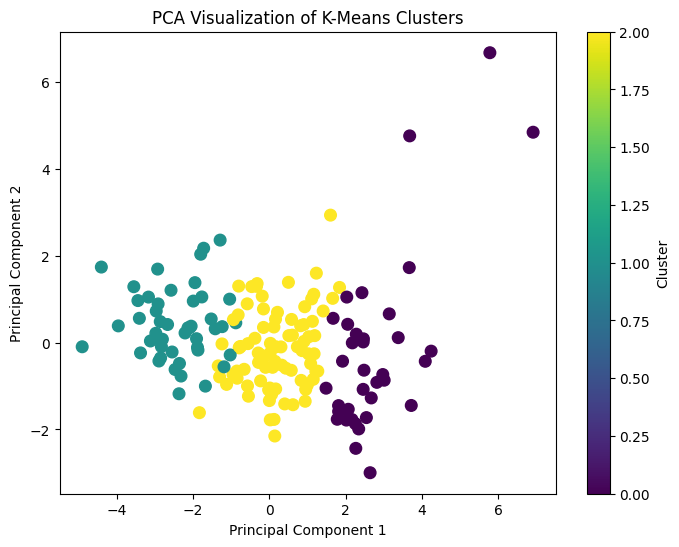

In [10]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="viridis",
    s=70
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of K-Means Clusters")

plt.colorbar(label="Cluster")
plt.show()

**Display Final Dataset**

In [11]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0


**Written** **Observations**

* Observation 1

Cluster 0 contains countries with high GDP, higher life expectancy, and better economic conditions.

* Observation 2

Cluster 1 mainly consists of developing nations with moderate income and moderate child mortality.

* Observation 3

Cluster 2 represents economically weaker countries with high child mortality, low GDP, and lower life expectancy.

* Observation 4

DBSCAN identified a few countries as noise/outliers, indicating unique socio-economic characteristics.

* Observation 5

The PCA visualization shows that K-Means forms reasonably well-separated clusters, indicating effective segmentation.